## Problem 1: Trip duration

### Part 1: Build a Regression Model

Build a regression to predict trip duration by using
- Day of time
- Distance between start and end stations (there might be more than one way to measure it)
- Hour of day
- Weekend indicator
- Don't forget to model bias (this one is intentionally not used in lecture)
- Also any thing you want to end

### Part 2: Experiment Design

- Ensure that you properly design your experiment to report unbiased performance metric you choose

### Part 3 [Optional]: Visualize

- Generate some fictional pickup and dropoff locations for bike trips (random pair selection)
- Estimate trip duration for those say 10 trips
- Visualize them on map using `pydeck` by using redish color for slower trips and greener for faster trips.

In [2]:
import duckdb
import pandas as pd
import numpy as np

df = duckdb.sql("""
SELECT
    starttime,
    stoptime,
    "start station latitude" AS start_lat,
    "start station longitude" AS start_lon,
    "end station latitude" AS end_lat,
    "end station longitude" AS end_lon,
    usertype,
    gender,
    "birth year" AS birth_year
FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'
WHERE random() < 0.03""").df()

df.head()

,starttime,stoptime,start_lat,start_lon,end_lat,end_lon,usertype,gender,birth_year
0,1/1/2015 0:10,1/1/2015 0:20,40.748238,-73.978311,40.738177,-73.977387,Subscriber,1,1991.0
1,1/1/2015 0:55,1/1/2015 1:21,40.743453,-74.000040,40.743453,-74.000040,Subscriber,1,1964.0
2,1/1/2015 1:05,1/1/2015 1:13,40.725029,-73.990697,40.732233,-73.988900,Subscriber,2,1969.0
3,1/1/2015 1:37,1/1/2015 1:44,40.711731,-73.991930,40.725029,-73.990697,Subscriber,1,1989.0
4,1/1/2015 1:40,1/1/2015 1:47,40.732219,-73.981656,40.741444,-73.975361,Subscriber,2,1988.0


In [12]:
df["start_at"] = pd.to_datetime(df["starttime"],errors="coerce",format="mixed")
df["stop_at"] = pd.to_datetime(df["stoptime"],errors="coerce",format="mixed")

df["duration_min"] = ( df["stop_at"] - df["start_at"] ).dt.total_seconds() / 60

In [21]:
df = df[
    (df["duration_min"] >= 1) &
    (df["duration_min"] <= 180)
].copy()

print(df["duration_min"].describe())

count    710603.000000
mean         13.784124
std          12.174984
min           1.000000
25%           6.383333
50%          10.466667
75%          17.633333
max         179.966667
Name: duration_min, dtype: float64


In [23]:
import numpy as np
import pandas as pd

df["hour"] = df["start_at"].dt.hour
df["day_of_week"] = df["start_at"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

In [24]:
def manhattan_distance(lat1, lon1, lat2, lon2):
    R = 6371 

    lat1_rad = np.radians(lat1)
    lat2_rad = np.radians(lat2)

    lat_distance = R * np.abs(np.radians(lat2 - lat1))

    mean_lat = (lat1_rad + lat2_rad) / 2
    lon_distance = R * np.cos(mean_lat) * np.abs(np.radians(lon2 - lon1))

    return lat_distance + lon_distance

In [25]:
df["manhattan_km"] = manhattan_distance(
    df["start_lat"],
    df["start_lon"],
    df["end_lat"],
    df["end_lon"]
)

In [30]:
features = ["manhattan_km", "hour", "day_of_week", "is_weekend"]

X = df[features]
y = df["duration_min"]

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [36]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Bias:", model.intercept_)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

Bias: 12.068228959308367
MAE: 7.845486342105091
RMSE: 12.120808367202056
R2: 0.011141584686984563


### Problem 2: Extending Naive Bayesian

### Part 1: Expand the NB Regression Idea to continous variable

$$
P(gender = a, speed_{bike} = x) = P(gender = a) P(speed_{bike} = x | gender = a)
$$

- Note that $P(speed_{bike} = x | gender = a)$ is  continous distribution.
- Expand the idea
- Build a predictive model for estimation biker gender using the bike speed ?

### Part 2: Use Visualization to decide best distribution 

- How should be $P(speed_{bike} = x | gender = a)$ modeled

In [39]:
df["speed_kmh"] = df["manhattan_km"] / (df["duration_min"] / 60)
df[["manhattan_km", "duration_min", "speed_kmh", "gender"]].head()

,manhattan_km,duration_min,speed_kmh,gender
0,1.196663,10.0,7.179978,1
1,0.000000,26.0,0.000000,1
2,0.952466,8.0,7.143496,2
3,1.582623,7.0,13.565340,1
4,1.556169,7.0,13.338594,2


In [40]:
print(df["speed_kmh"].describe())
print(df["gender"].value_counts())

count    710603.000000
mean         11.953189
std         560.850276
min           0.000000
25%           8.644096
50%          11.272931
75%          13.944529
max      464018.259662
Name: speed_kmh, dtype: float64
gender
1    474144
2    149125
0     87334
Name: count, dtype: int64


In [41]:
nb_df = df[
    (df["gender"].isin([1, 2])) &
    (df["speed_kmh"] >= 1) &
    (df["speed_kmh"] <= 40)
].copy()

print(nb_df["speed_kmh"].describe())
print(nb_df["gender"].value_counts())

count    612253.000000
mean         11.905711
std           3.776952
min           1.000477
25%           9.421969
50%          11.770167
75%          14.310727
max          37.572713
Name: speed_kmh, dtype: float64
gender
1    465824
2    146429
Name: count, dtype: int64


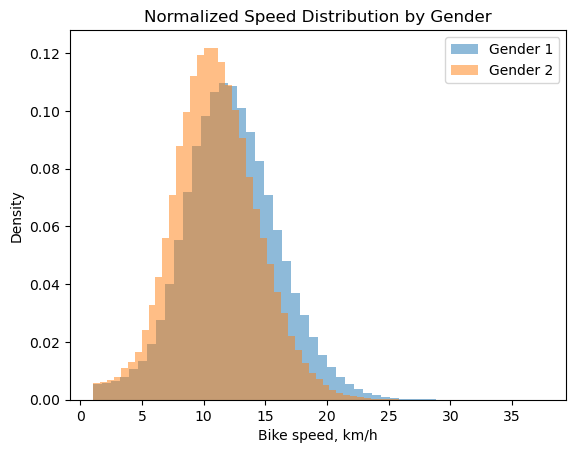

In [43]:
plt.hist(
    nb_df[nb_df["gender"] == 1]["speed_kmh"],
    bins=50,
    alpha=0.5,
    density=True,
    label="Gender 1"
)

plt.hist(
    nb_df[nb_df["gender"] == 2]["speed_kmh"],
    bins=50,
    alpha=0.5,
    density=True,
    label="Gender 2"
)

plt.xlabel("Bike speed, km/h")
plt.ylabel("Density")
plt.title("Normalized Speed Distribution by Gender")
plt.legend()
plt.show()

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

X = nb_df[["speed_kmh"]]
y = nb_df["gender"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

y_pred = nb_model.predict(X_test)

In [46]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.7608349462233873
Confusion Matrix:
[[93165     0]
 [29286     0]]
              precision    recall  f1-score   support

           1       0.76      1.00      0.86     93165
           2       0.00      0.00      0.00     29286

    accuracy                           0.76    122451
   macro avg       0.38      0.50      0.43    122451
weighted avg       0.58      0.76      0.66    122451

